In [6]:
# importa o modulo de datasets
from torchvision import datasets
import torch
# define o caminho da pasta onde o dataset sera armazenado
data_folder = '~/data/FMNIST'
# carrega o dataset do FashionMNIST
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

In [8]:
# extrai os dados das imagens e os rotulos
tr_images = fmnist.data
tr_targets = fmnist.targets

In [10]:
# importação das bibliotecas de plotagem e manipulação
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

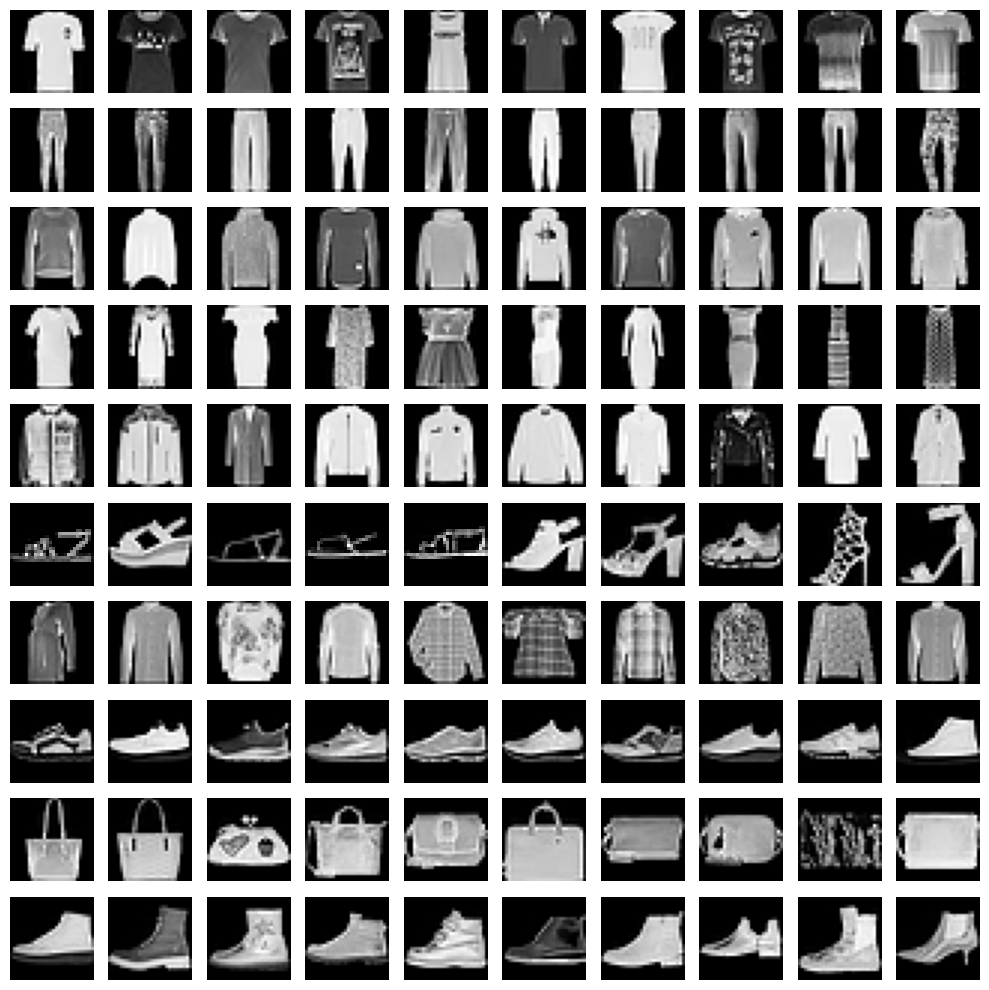

In [11]:
R, C = len(tr_targets.unique()), 10 # define o número de linhas
fig, ax = plt.subplots(R, C, figsize=(10,10)) # cria uma grade de subplots

for label_class, plot_row in enumerate(ax): # itera por cada classe
    label_x_rows = np.where(tr_targets == label_class)[0] # encontra os indices

    for plot_cell in plot_row: # preenche cada celula
        plot_cell.grid(False); plot_cell.axis('off') # remove grades e eixos
        ix = np.random.choice(label_x_rows) # escolhe um indice aleatório
        x, y = tr_images[ix], tr_targets[ix] # obtém a imagem e o rótulo
        plot_cell.imshow(x, cmap='gray') # plota em tons de cinza

# ajusta o layout
plt.tight_layout()

In [12]:
# importação de bibliotecas para manipulação de dados tensores redes neurais e datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets

In [13]:
# definição da classe customizada para o dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28) # pega a imagem 28x28 em um vetor único de 784 elementos
        self.x, self.y = x, y

    # retorna um item
    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x.to(device), y.to(device)

    # retorna o total
    def __len__(self):
        return len(self.x)

In [15]:
# função para criar o dataloader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True) # significa que o modelo vera 32 imagens
    return trn_dl

In [16]:
from torch.optim import SGD

# função para instanciar o modelo
def get_model():
    # cria uma rede sequencial
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss é ideal
    optimizer = SGD(model.parameters(), lr=1e-2) # otimizador

    return model, loss_fn, optimizer

In [17]:
# decorador que desativa
@torch.no_grad()
def accuracy(x, y, model):
    model.eval() # coloca o modelo em modo de avaliação)
    prediction = model(x) # obtém as predições
    max_values, argmaxes = prediction.max(-1) # seleciona o índice
    is_correct = argmaxes == y # compara o indice
    return is_correct.cpu().numpy().tolist() # converte o resultado

In [18]:
# define a função responsavel por treinar
def train_batch(x, y, model, opt, loss_fn):
    model.train() # coloca o modelo em modo de treinamento
    prediction = model(x)
    batch_loss = loss_fn(prediction, y) # calcula o erro
    batch_loss.backward() # retropropagação
    optimizer.step() # atualiza os pesos do modelo
    optimizer.zero_grad() # limpa a memoria

    # retorna o valor da perda
    return batch_loss.item()

In [20]:
trn_dl = get_data() # inicializa o carregador de dados
model, loss_fn, optimizer = get_model() # cria o modelo

In [21]:
# inicializa listas para armazenar
losses, accuracies = [], []

# loop principal
for epoch in range(5):
    print(epoch)
    epoch_losses, epoch_accuracies = [], [] # listas temporarias
    # percorre todos os lotes
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)

    # calcula a média da perda
    epoch_loss = np.array(epoch_losses).mean()

    # percorre o dataset novamente
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)

    # calcula a média de acertos
    epoch_accuracy = np.mean(epoch_accuracies)

    # guarda os resultados finais
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

0
1
2
3
4


/tmp/ipykernel_7081/3005644948.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


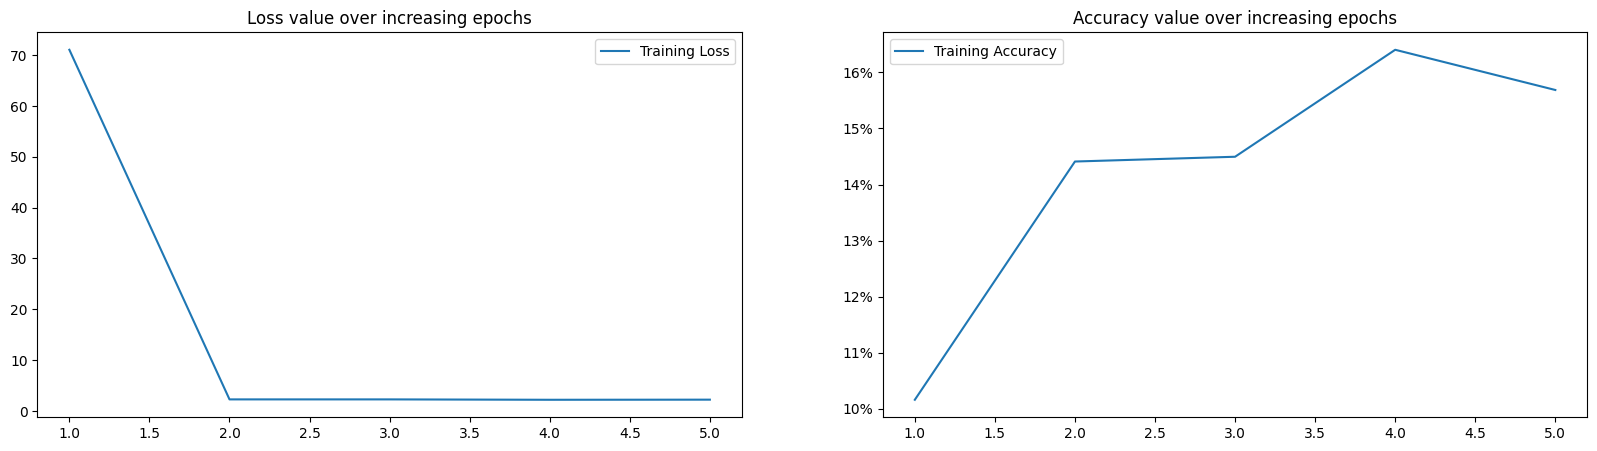

In [22]:
# cria um array de 1 a 5
epochs = np.arange(5) + 1
# define o tamanho da figura para comportar dois graficos
plt.figure(figsize=(20, 5))


plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()

plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')

# formata o eixo Y para exibir valores
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()